# Instructions
Welcome to the Horse or Human Model Project, developed as part of the TinyML course offered by Harvard University on edX. This project demonstrates how to perform computer vision and explores techniques such as data augmentation to improve the accuracy of a convolutional neural network using TensorFlow and Keras. The model classifies images from the Horse or Human dataset provided by Google.

To test the model, open the notebook and click Runtime, then select Run All. After a few seconds you will be prompted to upload images from your own device. Youll find this at the final section(last cell)

The model has been specifically trained to distinguish between horses and humans, but for fun you can also upload your own photos and see how the classifier responds.

Hope you enjoy exploring the project.

In [2]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

## Download the neccessary data into the Colab Instance

In [3]:
!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/horse-or-human.zip \
    -O /tmp/horse-or-human.zip #downloads horse-or-human.zip and saves it to /tmp/horse-or-human.zip


!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/validation-horse-or-human.zip \
    -O /tmp/validation-horse-or-human.zip #validation-horse-or-human.zip and saves it to /tmp/validation-horse-or-human.zip

--2026-03-09 11:48:56--  https://storage.googleapis.com/learning-datasets/horse-or-human.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.12.207, 172.253.118.207, 74.125.200.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.12.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 149574867 (143M) [application/zip]
Saving to: ‘/tmp/horse-or-human.zip’

/tmp/horse-or-human 100%[===================>] 142.65M  23.5MB/s    in 7.6s    

2026-03-09 11:49:04 (18.9 MB/s) - ‘/tmp/horse-or-human.zip’ saved [149574867/149574867]

--2026-03-09 11:49:04--  https://storage.googleapis.com/learning-datasets/validation-horse-or-human.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.12.207, 172.253.118.207, 74.125.200.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.12.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11480187 (11M) [application/zi

In [4]:
import os
import zipfile

'''
Extracting content from zip directory to normal directories
This is so as to return the images into their normal state
Decompressing them allows software to work with them
/tmp is a standard directory in Unix-like operating systems (like Linux, which Colab environments are based on).
'''

local_zip = '/tmp/horse-or-human.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')#opens the ZIP file specified by local_zip in read mode ('r') and creates a ZipFile object
zip_ref.extractall('/tmp/horse-or-human')#extracts all the contents of the opened ZIP file into the directory
local_zip = '/tmp/validation-horse-or-human.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp/validation-horse-or-human')
zip_ref.close()

In [5]:
'''
os.path.join
Its main purpose is to intelligently concatenate path components, creating a full file or directory path.
'''


# Directory with our training horse pictures
train_horse_dir = os.path.join('/tmp/horse-or-human/horses')
# Directory with our training human pictures
train_human_dir = os.path.join('/tmp/horse-or-human/humans')
# Directory with our training horse pictures
validation_horse_dir = os.path.join('/tmp/validation-horse-or-human/horses')
# Directory with our training human pictures
validation_human_dir = os.path.join('/tmp/validation-horse-or-human/humans')


# Visualizing first 10 contents of each directory in the main folder.

In [6]:
train_horse_names = os.listdir('/tmp/horse-or-human/horses')
print(train_horse_names[:10])
train_human_names = os.listdir('/tmp/horse-or-human/humans')
print(train_human_names[:10])
validation_horse_hames = os.listdir('/tmp/validation-horse-or-human/horses')
print(validation_horse_hames[:10])
validation_human_names = os.listdir('/tmp/validation-horse-or-human/humans')
print(validation_human_names[:10])

['horse25-7.png', 'horse48-6.png', 'horse36-2.png', 'horse15-9.png', 'horse01-7.png', 'horse14-4.png', 'horse23-2.png', 'horse50-0.png', 'horse24-0.png', 'horse45-3.png']
['human11-14.png', 'human15-23.png', 'human09-19.png', 'human16-10.png', 'human10-30.png', 'human02-02.png', 'human14-03.png', 'human10-05.png', 'human03-27.png', 'human01-01.png']
['horse5-018.png', 'horse1-568.png', 'horse5-458.png', 'horse5-400.png', 'horse5-032.png', 'horse3-171.png', 'horse2-314.png', 'horse5-550.png', 'horse6-064.png', 'horse3-141.png']
['valhuman03-03.png', 'valhuman01-09.png', 'valhuman01-14.png', 'valhuman02-13.png', 'valhuman01-12.png', 'valhuman02-06.png', 'valhuman01-16.png', 'valhuman05-17.png', 'valhuman04-11.png', 'valhuman03-11.png']


In [7]:
import tensorflow as tf

## Define your model and optimizer

In [8]:
model = tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image with 3 bytes color
    # This is the first convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    # The second convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The third convolution
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fourth convolution
    tf.keras.layers.Conv2D(256, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    # Only 1 output neuron. It will contain a value from 0-1 where 0 for 1 class
    # ('horses') and 1 for the other ('humans')
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Building Model architecture

In [9]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,617,665 (9.99 MB)

 Trainable params: 2,617,665 (9.99 MB)

 Non-trainable params: 0 (0.00 B)

None


# Model Compilation

In [10]:
from tensorflow.keras.optimizers import RMSprop
optimizer = RMSprop(learning_rate=0.0001)
model.compile(loss='binary_crossentropy',
              optimizer=optimizer,
              metrics=['acc'])

## Organize your data into Generators

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# All images will be augmented according to whichever lines are uncommented
# below. We can first try without any of the augmentation beyond the rescaling
train_datagen = ImageDataGenerator(
      rescale=1./255, #normalizing images
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest'
      )





# Creating iterator

```flow_from_dierctory```- applies transformations defined under the image generator to the parents directory also resizes the image and does this in batch sizes of 128

The subdirectories names are inherited as labels but when organized into batches each image carries its own label since they are mixed/shuffled.


In [14]:
# Flow training images in batches of 128 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        '/tmp/horse-or-human/',  # This is the source directory for training images
        target_size=(100, 100),  # All images will be resized to 100x100
        batch_size=128,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

Found 1027 images belonging to 2 classes.


# Creating Validation Generator

In [15]:
validation_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = validation_datagen.flow_from_directory(
        '/tmp/validation-horse-or-human',
        target_size=(100, 100),
        class_mode='binary')


Found 256 images belonging to 2 classes.


## Train your model
This may take a little while. Remember we are now building and training relatively complex computer vision models!

In [16]:
history = model.fit(
      train_generator,
      steps_per_epoch=8,
      epochs=100,
      verbose=1,
      validation_data=validation_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - acc: 0.5372 - loss: 0.6868 - val_acc: 0.6367 - val_loss: 0.6779
Epoch 2/100
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.6406 - loss: 0.6847

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - acc: 0.6406 - loss: 0.6847 - val_acc: 0.5039 - val_loss: 0.6757
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - acc: 0.5134 - loss: 0.6852 - val_acc: 0.5000 - val_loss: 0.6833
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - acc: 0.5000 - loss: 0.6861 - val_acc: 0.5000 - val_loss: 0.6791
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - acc: 0.5929 - loss: 0.6859 - val_acc: 0.5391 - val_loss: 0.6605
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - acc: 0.6797 - loss: 0.6652 - val_acc: 0.5000 - val_loss: 0.6661
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - acc: 0.5732 - loss: 0.6856 - val_acc: 0.8008 - val_loss: 0.6389
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - acc: 0.6953 - loss: 0.6540 - val_acc: 0.7344 - val_loss: 0.6353
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - acc: 0.6747 - loss: 0.6536 - val_acc: 0.5000 - val_loss: 0.6859
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - acc: 0.5781 - loss: 0.6540 - val_acc:

In [26]:
print(len(model.layers))

12


# Visualizing model layers!

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step


/tmp/ipykernel_1387/1262754198.py:66: RuntimeWarning: invalid value encountered in divide
  x /= x.std()
/tmp/ipykernel_1387/1262754198.py:69: RuntimeWarning: invalid value encountered in cast
  x = np.clip(x, 0, 255).astype('uint8')#limits the range between 0-255 and converts them to uint8 std dtype for pixels


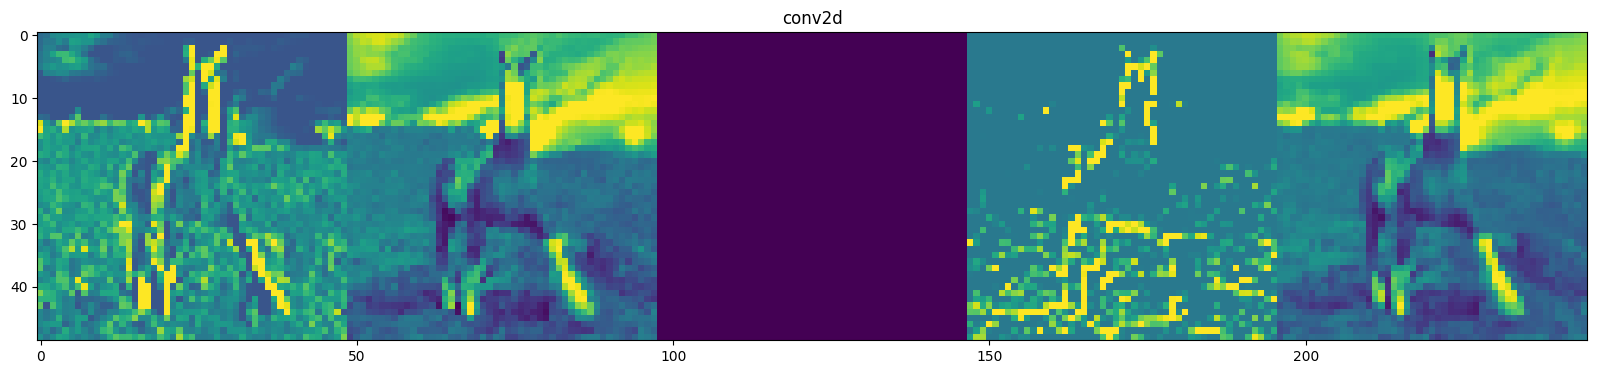

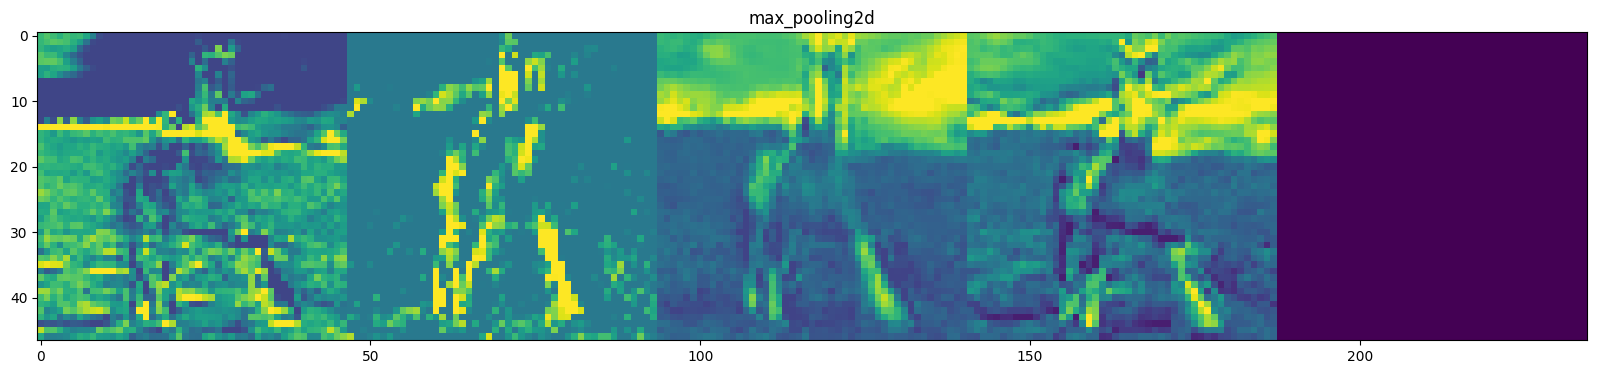

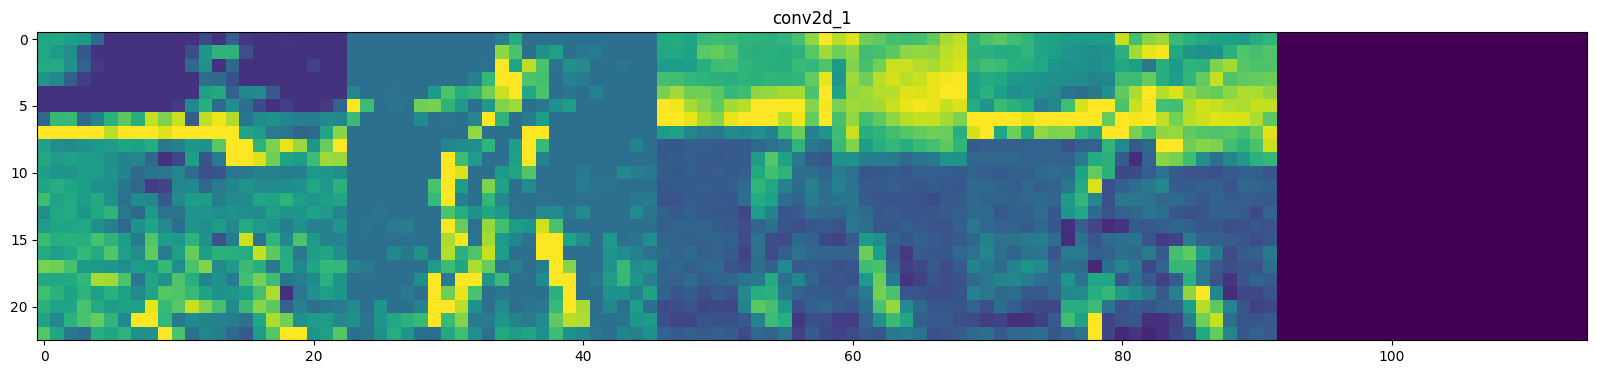

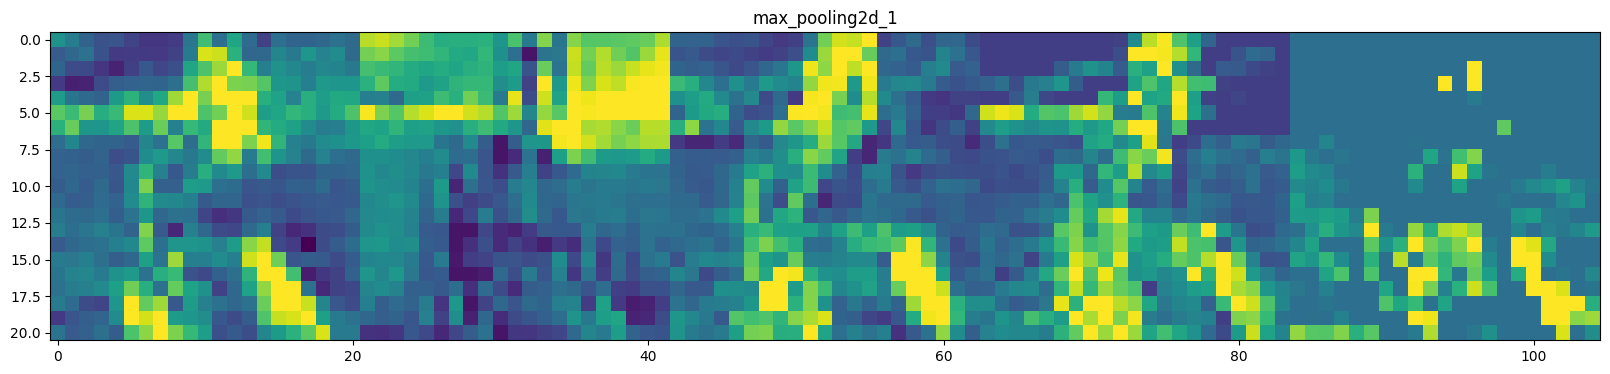

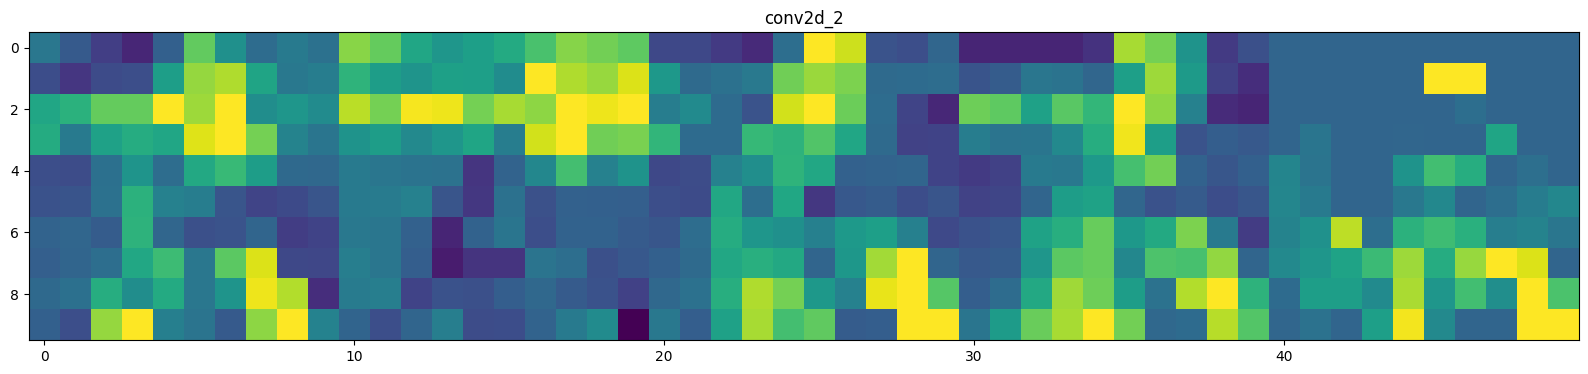

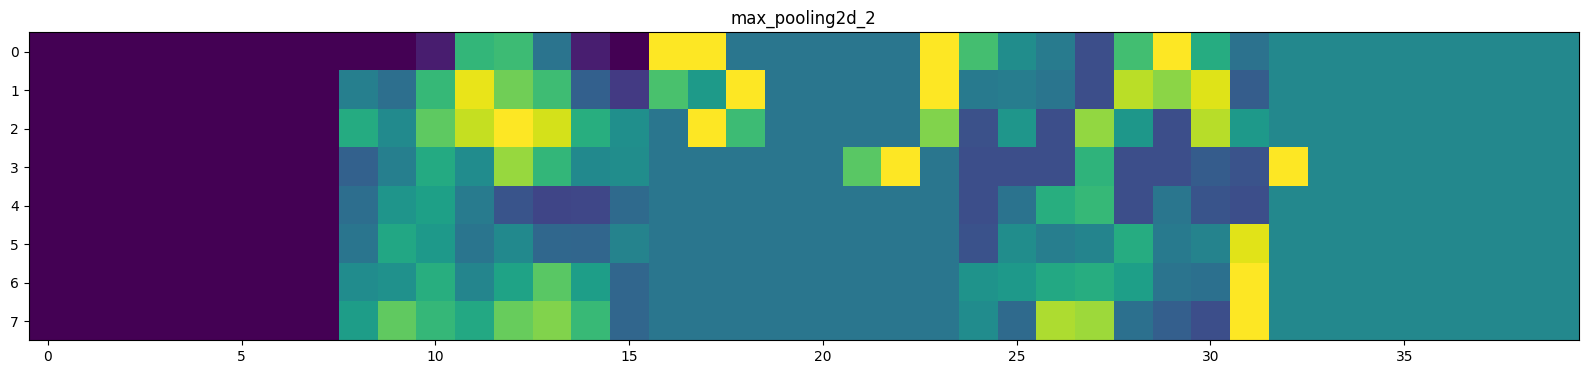

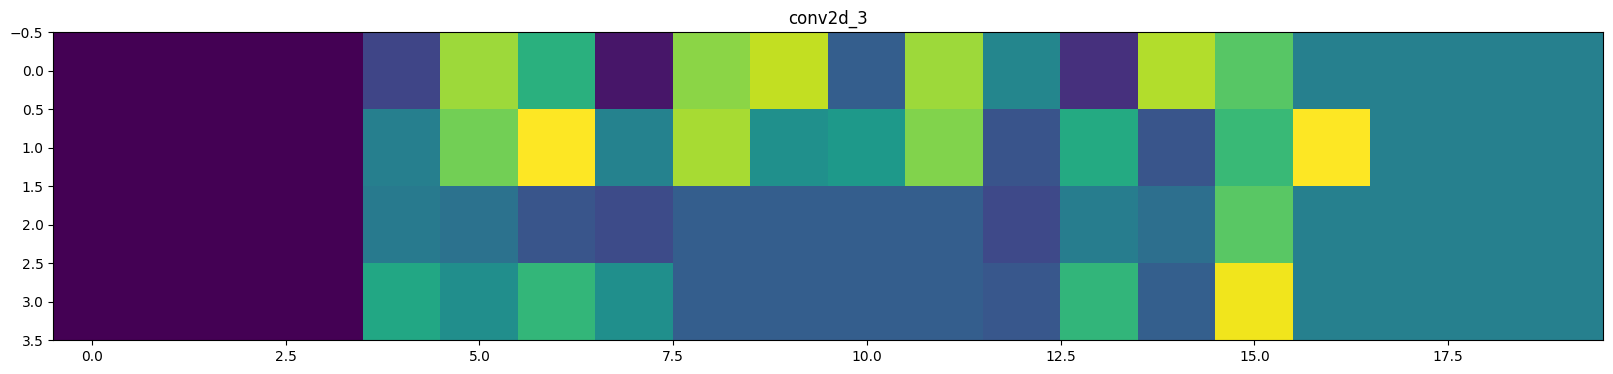

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import random
from tensorflow.keras.preprocessing.image import img_to_array, load_img

%matplotlib inline
#ensures Matplotlib plots are displayed directly within the notebook output.

import matplotlib.pyplot as plt
import matplotlib.image as mpimg


successive_outputs = [layer.output for layer in model.layers[1:]] #get outputs of separate layers
'''
A new Keras Model is created.
This visualization_model takes the same input as the original model but outputs the activations from the intermediate layers defined in successive_outputs.
'''

visualization_model = tf.keras.models.Model(inputs = model.inputs, outputs = successive_outputs)

horse_img_files = [os.path.join(train_horse_dir, f) for f in train_horse_names]#creates a list of full path names to horse images.
human_img_files = [os.path.join(train_human_dir, f) for f in train_human_names]#creates a list of full path names to human images.


'''
concatenates (joins) the two lists of image paths into one single list containing all horse and human image paths.
random.choice(...) then picks one random path from this combined list.
'''
img_path = random.choice(horse_img_files + human_img_files)

#img_path = human_img_files[0]

img = load_img(img_path, target_size=(100, 100))  # this is a PIL image
x = img_to_array(img)  # Numpy array with shape (100, 100, 3)
x = x.reshape((1,) + x.shape)  # Numpy array with shape (1, 100, 100, 3)

# Rescale by 1/255
x /= 255.0

#obtaining all intermediate representations for this image.

successive_feature_maps = visualization_model.predict(x)

# names of the layers
layer_names = [layer.name for layer in model.layers]

# Now let's display our representations
for layer_name, feature_map in zip(layer_names, successive_feature_maps):
  if len(feature_map.shape) == 4:
    # Just do this for the conv / maxpool layers, not the fully-connected layers
    n_features = feature_map.shape[-1]  # number of features in feature map
    n_features = min(n_features,5) # limit to 5 features for easier viewing
    # The feature map has shape (1, size, size, n_features)
    size = feature_map.shape[1]
    # We will tile our images in this matrix
    display_grid = np.zeros((size, size * n_features))
    for i in range(n_features):
      '''
      This line extracts a single 2D feature map from the feature_map tensor.
      feature_map has a shape like (1, height, width, channels).
      [0] selects the first (and only) image in the batch, [:, :] selects all rows and columns (the height and width), and [i] selects the i-th channel (or filter) of that feature map.
      So, x now represents a single 2D grayscale image showing the activations for one specific filter.
      '''
      x = feature_map[0, :, :, i]
      x -= x.mean()
      x /= x.std()
      x *= 64
      x += 128
      x = np.clip(x, 0, 255).astype('uint8')#limits the range between 0-255 and converts them to uint8 std dtype for pixels
      # We'll tile each filter into this big horizontal grid
      '''
      display_grid[:, ...] selects all rows
      display_grid[:, i * size : (i + 1) * size] selects the columns from i * size to
      '''
      display_grid[:, i * size : (i + 1) * size] = x

    # Display the grid
    scale = 20. / n_features
    plt.figure(figsize=(scale * n_features, scale))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

## Clean Up

Before running the next exercise, run the following cell to terminate the kernel and free memory resources:

In [ ]:
import os, signal
os.kill(os.getpid(), signal.SIGKILL)

# Mechanism of zip()

In [27]:
list1 = [('kevin','nyakundi'),('pilau','chapati')]
list2 = ['humans','foods']
for human,food in zip(list1,list2):
  print(human,food)

('kevin', 'nyakundi') humans
('pilau', 'chapati') foods


In [30]:
print(list(zip(list1,list2)))

[(('kevin', 'nyakundi'), 'humans'), (('pilau', 'chapati'), 'foods')]


## Upload your chosen images

Let's now take a look at actually running a prediction using the model. This code will allow you to choose 1 or more files from your file system, it will then upload them, and run them through the model, giving an indication of whether the object is a horse or a human. **Was the model correct? Try a couple more images and see if you can confuse it!**

Saving Screenshot 2026-03-09 164155.png to Screenshot 2026-03-09 164155 (1).png
Saving Screenshot 2026-03-09 155800.png to Screenshot 2026-03-09 155800 (3).png
Saving Screenshot 2026-03-09 155724.png to Screenshot 2026-03-09 155724 (4).png
Saving Screenshot 2026-03-09 155658.png to Screenshot 2026-03-09 155658 (5).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.51963156]]
[0.51963156]
Screenshot 2026-03-09 164155 (1).png is a human


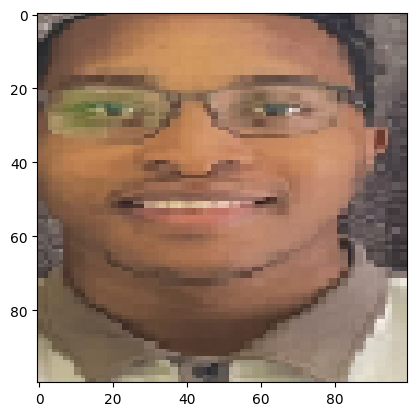

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.42479727]]
[0.42479727]
Screenshot 2026-03-09 155800 (3).png is a horse


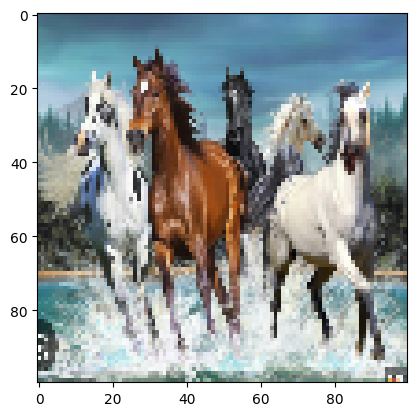

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.53038234]]
[0.53038234]
Screenshot 2026-03-09 155724 (4).png is a human


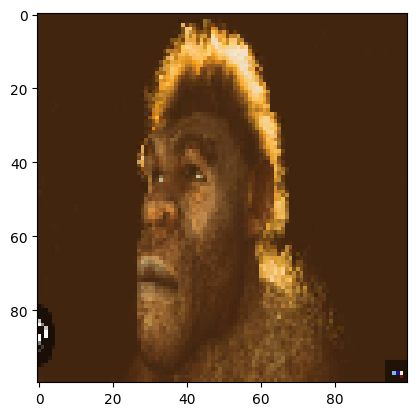

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.52275693]]
[0.52275693]
Screenshot 2026-03-09 155658 (5).png is a human


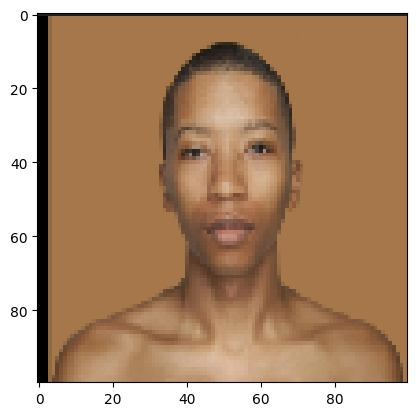

In [25]:
import numpy as np
from google.colab import files
from tensorflow.keras import utils
import matplotlib.pyplot as plt


# predicting images

uploaded = files.upload()

for fn in uploaded.keys():

  # predicting images
  path = '/content/' + fn
  img = utils.load_img(path, target_size=(100, 100))
  x = utils.img_to_array(img)
  x = x / 255.0
  x = np.expand_dims(x, axis=0)

  image_tensor = np.vstack([x])
  classes = model.predict(image_tensor)
  print(classes)
  print(classes[0])
  if classes[0]>0.5:
    print(fn + " is a human")
    plt.imshow(img)
    plt.show()
  else:
    print(fn + " is a horse")
    plt.imshow(img)
    plt.show()